# House Price Prediction System — Improved V2
## Complete End-to-End Machine Learning Notebook

**Problem:** House Price Prediction — Regression  
**Dataset:** `house_prices.csv.gz`  
**Public Source:** Kaggle — *House Price* by Juhi Bhojani  
**URL:** https://www.kaggle.com/datasets/juhibhojani/house-price

---

## Objective
Build a reproducible machine-learning system that predicts the **total listed house price in Indian Rupees** using property configuration and location-related information.

### Complete lifecycle
**Data Collection → Data Understanding → Data Cleaning → EDA → Preprocessing → Feature Engineering → Model Training → Model Comparison → Evaluation → Model Saving → Application/API Development → Deployment**

### V2 improvement goal
The first version achieved a test R² around **0.785**. V2 improves the model without using target leakage by adding locality/project context and a stronger boosting algorithm.

# 1. Import Libraries

We use Pandas and NumPy for data work, Matplotlib for EDA, Scikit-learn for evaluation/pipelines, LightGBM for improved nonlinear modeling, and Joblib for model persistence.

In [1]:
from pathlib import Path
import sys, time, json, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

ROOT = Path.cwd()
if not (ROOT / "data" / "house_prices.csv.gz").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from data_utils import DATASET_SOURCE_NAME, DATASET_SOURCE_URL, RAW_INPUT_FEATURES, build_modeling_table
from preprocessing import FeatureEngineerV2, NativeCategoryPreprocessor, build_target_encoder_preprocessor

DATA_PATH = ROOT / "data" / "house_prices.csv.gz"
RANDOM_STATE = 42
print(ROOT)

/mnt/data/House_Price_Prediction_System_Improved_V2


# 2. Data Collection

The project uses a genuine publicly available Kaggle dataset. The raw CSV contains property listing title, amount, price-per-area style information, city/location, carpet/super area, floor, transaction, furnishing, facing, society, bathrooms, balconies, parking and ownership information.

The target is built from **`Amount(in rupees)`**. Strings such as `42 Lac` and `1.40 Cr` are converted to numeric INR.

In [2]:
raw = pd.read_csv(DATA_PATH)
print("Dataset source:", DATASET_SOURCE_NAME)
print("Source URL:", DATASET_SOURCE_URL)
print("Raw shape:", raw.shape)
raw.head()

Dataset source: House Price by Juhi Bhojani
Source URL: https://www.kaggle.com/datasets/juhibhojani/house-price
Raw shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


# 3. Data Understanding

Before transforming anything, we inspect shape, data types, missing values and cardinality. This dataset is a good academic example because it contains many real-world data-quality issues instead of already-clean numeric columns.

In [3]:
summary = pd.DataFrame({
    "Column": raw.columns,
    "Dtype": [str(raw[c].dtype) for c in raw.columns],
    "Missing": [int(raw[c].isna().sum()) for c in raw.columns],
    "Unique": [int(raw[c].nunique(dropna=True)) for c in raw.columns],
})
summary

,Column,Dtype,Missing,Unique
0,Index,int64,0,187531
1,Title,object,0,32446
2,Description,object,3023,65634
3,Amount(in rupees),object,0,1561
4,Price (in rupees),float64,17665,10958
5,location,object,0,81
6,Carpet Area,object,80673,2758
7,Status,object,615,1
8,Floor,object,7077,947
9,Transaction,object,83,4


## Key observations

- `Dimensions` and `Plot Area` are completely missing and cannot contribute useful information.
- `Status` is nearly constant.
- `Society`, `Car Parking`, `facing`, `overlooking`, `Carpet Area` and `Super Area` contain substantial missingness.
- `Floor` is a compound string such as `10 out of 29`.
- Area values can use different units.
- `Title` contains useful BHK, property-type and locality clues.
- `Price (in rupees)` behaves like a price-per-area field and is **excluded from predictors** to prevent circular target leakage.

In [4]:
for c in ["Amount(in rupees)", "location", "Transaction", "Furnishing", "Society"]:
    print("\n---", c, "---")
    display(raw[c].value_counts(dropna=False).head(10))


--- Amount(in rupees) ---


Amount(in rupees)
Call for Price    9684
85 Lac            5264
65 Lac            4229
60 Lac            3869
70 Lac            3801
35 Lac            3369
75 Lac            3144
90 Lac            3143
40 Lac            3098
50 Lac            3006
Name: count, dtype: int64


--- location ---


location
new-delhi        27599
bangalore        24030
kolkata          22380
gurgaon          20070
ahmedabad        12750
hyderabad        12300
chennai          10500
jaipur            8490
greater-noida     4710
faridabad         3840
Name: count, dtype: int64


--- Transaction ---


Transaction
Resale          144172
New Property     42565
Other              709
NaN                 83
Rent/Lease           2
Name: count, dtype: int64


--- Furnishing ---


Furnishing
Semi-Furnished    88318
Unfurnished       76154
Furnished         20162
NaN                2897
Name: count, dtype: int64


--- Society ---


Society
NaN                           109678
Hamdam Apartment                1648
Malibu Town                     1158
Shree Vardhman Victoria         1154
DLF Skycourt                    1153
Nebula Tower                     982
Harmony Apartment                828
Defence Officers Apartment       827
East of Kailash                  826
Sarve Satyam Apartment           825
Name: count, dtype: int64

# 4. Data Cleaning

V2 performs the following transformations:

1. Lac/Cr price strings → numeric INR.
2. `Call for Price` → missing target and removed from supervised training.
3. Carpet/Super Area units → square feet.
4. Carpet Area preferred, Super Area used as fallback.
5. BHK and property type extracted from `Title`.
6. Floor split into current floor and total floors.
7. Bathroom, balcony and parking counts parsed.
8. Categorical text normalized.
9. Implausible/extreme records filtered using documented domain bounds.
10. Duplicate-like normalized model rows removed.
11. A **locality hint** is extracted from the listing title after removing the society/project phrase where possible.

In [5]:
clean = build_modeling_table(raw)
print("Raw rows:", len(raw))
print("Clean modeling rows:", len(clean))
print("Rows removed/unusable:", len(raw) - len(clean))
print("Locations:", clean["location"].nunique())
print("Locality hints:", clean["locality_hint"].nunique())
print("Society/project values:", clean["society"].nunique())
clean.head()

Raw rows: 187531
Clean modeling rows: 63592
Rows removed/unusable: 123939
Locations: 81
Locality hints: 13076
Society/project values: 9981


,price,location,society,locality_hint,property_type,bhk,area_sqft,current_floor,total_floors,bathrooms,balconies,parking,transaction,furnishing,facing,ownership,overlooking
0,4200000.0,thane,srushti siddhi mangal murti complex,bhiwandi,apartment,1.0,500.0,10.0,11.0,1.0,2.0,NaN,resale,unfurnished,unknown,unknown,unknown
1,9800000.0,thane,dosti vihar,pokhran road,apartment,2.0,473.0,3.0,22.0,2.0,NaN,1.0,resale,semi-furnished,east,freehold,garden/park
2,14000000.0,thane,sunrise by kalpataru,kolshet road,apartment,2.0,779.0,10.0,29.0,2.0,NaN,1.0,resale,unfurnished,east,freehold,garden/park
3,2500000.0,thane,unknown,kasheli,apartment,1.0,530.0,1.0,3.0,1.0,1.0,NaN,resale,unfurnished,unknown,unknown,unknown
4,16000000.0,thane,tenx habitat raymond realty,pokhran road,apartment,2.0,635.0,20.0,42.0,2.0,NaN,1.0,resale,unfurnished,west,co-operative society,"garden/park, main road"


## 4.1 Missing values after cleaning

Optional numeric fields are not dropped blindly. The saved preprocessing pipeline learns median values from the training data and fills missing numerical fields consistently. Missing/rare categorical values are also handled safely.

In [6]:
missing = pd.DataFrame({
    "Missing Count": clean.isna().sum(),
    "Missing %": (clean.isna().mean() * 100).round(2),
}).sort_values("Missing %", ascending=False)
missing

,Missing Count,Missing %
parking,36831,57.92
balconies,17427,27.40
total_floors,2412,3.79
current_floor,2371,3.73
bathrooms,369,0.58
price,0,0.00
property_type,0,0.00
location,0,0.00
society,0,0.00
bhk,0,0.00


# 5. Exploratory Data Analysis (EDA)

We inspect the target distribution and important feature relationships. Real-estate prices are strongly right-skewed because premium properties can be many times more expensive than typical listings.

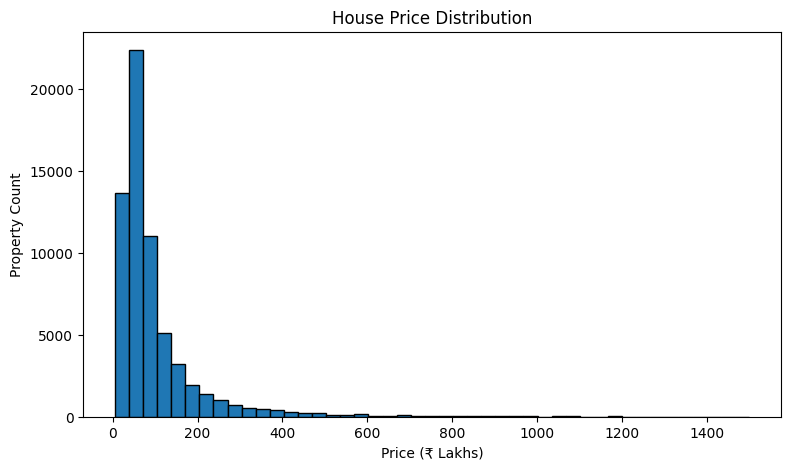

,Price INR
count,6.359200e+04
mean,9.951726e+06
std,1.174443e+07
min,5.000000e+05
50%,6.500000e+06
75%,1.080000e+07
90%,2.000000e+07
95%,3.000000e+07
99%,6.100000e+07
max,1.500000e+08


In [7]:
plt.figure(figsize=(9,5))
plt.hist(clean["price"] / 1e5, bins=45, edgecolor="black")
plt.title("House Price Distribution")
plt.xlabel("Price (₹ Lakhs)")
plt.ylabel("Property Count")
plt.show()

clean["price"].describe(percentiles=[.5,.75,.9,.95,.99]).to_frame("Price INR")

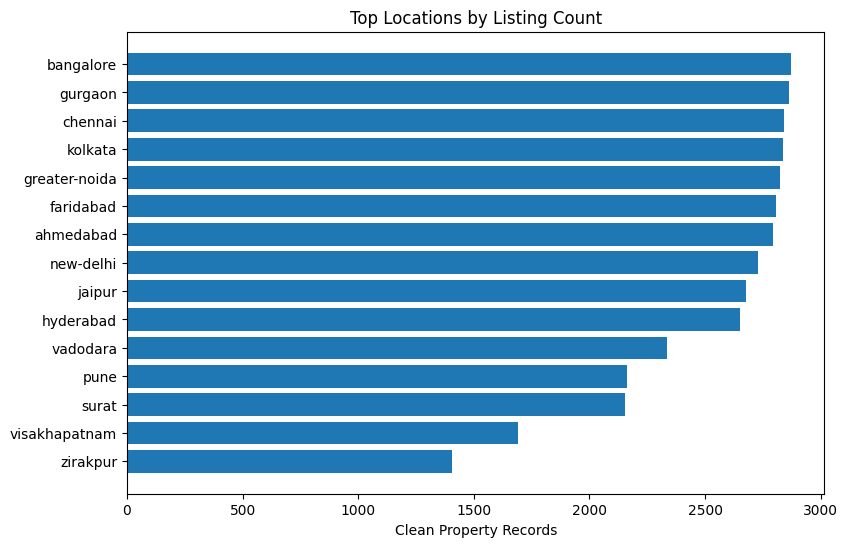

In [8]:
top_locations = clean["location"].value_counts().head(15).sort_values()
plt.figure(figsize=(9,6))
plt.barh(top_locations.index, top_locations.values)
plt.title("Top Locations by Listing Count")
plt.xlabel("Clean Property Records")
plt.show()

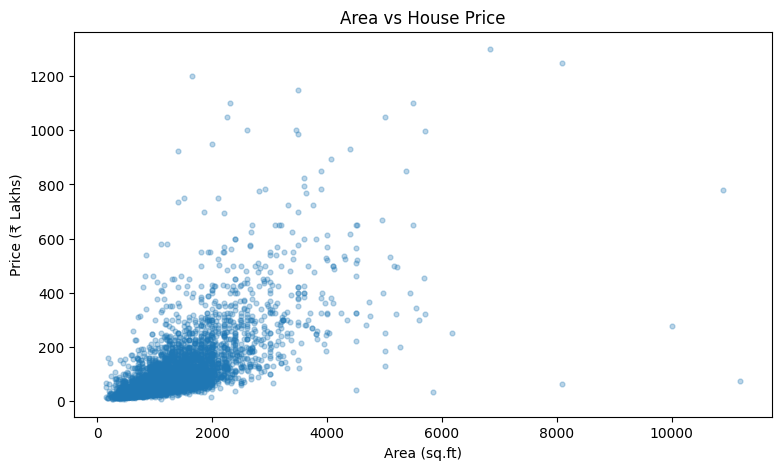

In [9]:
sample = clean.sample(min(6000, len(clean)), random_state=RANDOM_STATE)
plt.figure(figsize=(9,5))
plt.scatter(sample["area_sqft"], sample["price"] / 1e5, alpha=.3, s=12)
plt.title("Area vs House Price")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Price (₹ Lakhs)")
plt.show()

# 6. Feature Engineering

V2 adds more user-available information without using the target:

- **locality_hint** — derived from the title; captures neighborhood/area detail within a city.
- **society** — project/society name when available.
- **area_per_bhk** — spaciousness per bedroom configuration.
- **floor_ratio** — current floor relative to building height.
- **is_highrise** — whether total floors ≥ 10.
- **bath_per_bhk** and **balcony_per_bhk** — configuration ratios.
- **has_society** and **has_parking** — useful availability indicators.

This is the main reason V2 can model price differences more precisely than a city-only system.

In [10]:
engineer = FeatureEngineerV2()
engineered_preview = engineer.fit_transform(clean[RAW_INPUT_FEATURES].head(5))
engineered_preview

,location,locality_hint,society,property_type,bhk,area_sqft,current_floor,total_floors,bathrooms,balconies,parking,transaction,furnishing,facing,ownership,overlooking,area_per_bhk,floor_ratio,is_highrise,bath_per_bhk,balcony_per_bhk,has_society,has_parking
0,thane,bhiwandi,srushti siddhi mangal murti complex,apartment,1.0,500.0,10.0,11.0,1.0,2.0,NaN,resale,unfurnished,unknown,unknown,unknown,500.0,0.909091,1.0,1.0,2.0,1.0,0.0
1,thane,pokhran road,dosti vihar,apartment,2.0,473.0,3.0,22.0,2.0,NaN,1.0,resale,semi-furnished,east,freehold,garden/park,236.5,0.136364,1.0,1.0,NaN,1.0,1.0
2,thane,kolshet road,sunrise by kalpataru,apartment,2.0,779.0,10.0,29.0,2.0,NaN,1.0,resale,unfurnished,east,freehold,garden/park,389.5,0.344828,1.0,1.0,NaN,1.0,1.0
3,thane,kasheli,unknown,apartment,1.0,530.0,1.0,3.0,1.0,1.0,NaN,resale,unfurnished,unknown,unknown,unknown,530.0,0.333333,0.0,1.0,1.0,0.0,0.0
4,thane,pokhran road,tenx habitat raymond realty,apartment,2.0,635.0,20.0,42.0,2.0,NaN,1.0,resale,unfurnished,west,co-operative society,"garden/park, main road",317.5,0.476190,1.0,1.0,NaN,1.0,1.0


# 7. Preprocessing Strategy

Because the dataset contains high-cardinality categories such as locality and society, V2 uses two suitable preprocessing approaches:

### Baseline / HistGradientBoosting models
A cross-fitted **TargetEncoder** converts categorical values into numeric information while reducing direct leakage risk. Numerical values are median-imputed and scaled.

### LightGBM
The final candidate uses a custom native-category preprocessor that:
- learns medians from training data,
- learns valid category vocabularies,
- groups rare or unseen locality/society values into `other`,
- returns Pandas categorical columns so LightGBM can use native categorical splits.

All transformations live inside saved Scikit-learn pipelines.

# 8. Train / Validation / Test Split

V2 uses:
- **70% Training** — model fitting,
- **15% Validation** — model comparison and selection,
- **15% Test** — final untouched evaluation.

The test set is **not used to choose the winner**.

In [11]:
X = clean[RAW_INPUT_FEATURES].copy()
y = clean["price"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=.30, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=.50, random_state=RANDOM_STATE)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (44514, 16)
Validation: (9539, 16)
Test: (9539, 16)


# 9. Model Training

We compare three suitable regression algorithms:

1. **Linear Regression** — interpretable baseline.
2. **Histogram Gradient Boosting** — strong nonlinear Scikit-learn boosting model.
3. **LightGBM Regressor** — optimized gradient-boosted trees with native categorical handling.

Primary selection metric: **lowest validation RMSE**.

In [12]:
def target_pipeline(model):
    return Pipeline([
        ("feature_engineering", FeatureEngineerV2()),
        ("preprocessing", build_target_encoder_preprocessor()),
        ("model", model),
    ])

def lightgbm_pipeline():
    return Pipeline([
        ("feature_engineering", FeatureEngineerV2()),
        ("preprocessing", NativeCategoryPreprocessor(min_high_card_frequency=3)),
        ("model", LGBMRegressor(
            n_estimators=1800,
            learning_rate=.025,
            num_leaves=63,
            min_child_samples=20,
            subsample=.90,
            colsample_bytree=.90,
            reg_lambda=3.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )),
    ])

models = {
    "Linear Regression": target_pipeline(LinearRegression()),
    "HistGradientBoosting Regressor": target_pipeline(
        HistGradientBoostingRegressor(
            max_iter=550, learning_rate=.055, max_leaf_nodes=63,
            l2_regularization=3.0, random_state=RANDOM_STATE,
        )
    ),
    "LightGBM Regressor": lightgbm_pipeline(),
}

def metrics(y_true, pred):
    return {
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
        "R2": r2_score(y_true, pred),
    }

rows = []
for name, pipe in models.items():
    start = time.time()
    pipe.fit(X_train, y_train)
    val_pred = pipe.predict(X_val)
    rows.append({"Model": name, **metrics(y_val, val_pred), "Seconds": time.time()-start})

comparison = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
comparison

,Model,MAE,RMSE,R2,Seconds
0,LightGBM Regressor,2.083038e+06,4.286616e+06,0.863944,9.787131
1,HistGradientBoosting Regressor,2.152402e+06,4.393472e+06,0.857076,2.048874
2,Linear Regression,3.258381e+06,6.076371e+06,0.726613,0.591357


# 10. Model Comparison and Selection

Lower MAE/RMSE is better; higher R² is better. The winner is chosen by validation RMSE so the test set remains a final examination rather than a tuning resource.

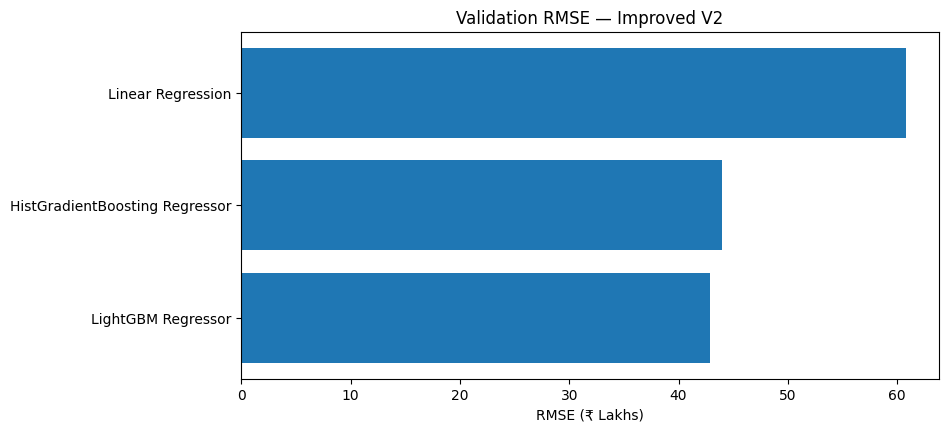

Selected model: LightGBM Regressor


In [13]:
plt.figure(figsize=(9,4.5))
plot_df = comparison.sort_values("RMSE")
plt.barh(plot_df["Model"], plot_df["RMSE"] / 1e5)
plt.title("Validation RMSE — Improved V2")
plt.xlabel("RMSE (₹ Lakhs)")
plt.show()

best_model_name = comparison.iloc[0]["Model"]
print("Selected model:", best_model_name)

# 11. Final Test Evaluation

After model selection, the chosen algorithm is retrained on **training + validation data** and evaluated once on the untouched test set.

In [14]:
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

final_model = lightgbm_pipeline() if best_model_name == "LightGBM Regressor" else models[best_model_name]
final_model.fit(X_trainval, y_trainval)
test_pred = final_model.predict(X_test)
final_metrics = metrics(y_test, test_pred)

print("Final model:", best_model_name)
print("Test MAE : ₹{:,.0f}".format(final_metrics["MAE"]))
print("Test RMSE: ₹{:,.0f}".format(final_metrics["RMSE"]))
print("Test R²  : {:.4f}".format(final_metrics["R2"]))

Final model: LightGBM Regressor
Test MAE : ₹2,073,430
Test RMSE: ₹4,243,778
Test R²  : 0.8649


## 11.1 Improvement over V1

V1 test R² was roughly **0.785**. V2 should be compared using the final output above, not the validation score. The improvement comes from better geographic/context features and stronger nonlinear modeling — **not** from adding price-per-square-foot leakage.

In [15]:
old_r2 = 0.7850025121
new_r2 = final_metrics["R2"]
print("V1 R²:", round(old_r2, 4))
print("V2 R²:", round(new_r2, 4))
print("Absolute R² improvement:", round(new_r2 - old_r2, 4))
print("Relative error-variance reduction: {:.1f}%".format((1 - (1-new_r2)/(1-old_r2))*100))

V1 R²: 0.785
V2 R²: 0.8649
Absolute R² improvement: 0.0799
Relative error-variance reduction: 37.2%


# 12. Actual vs Predicted

A strong model should place points near the diagonal. Premium properties remain harder to predict because the target distribution has a long upper tail.

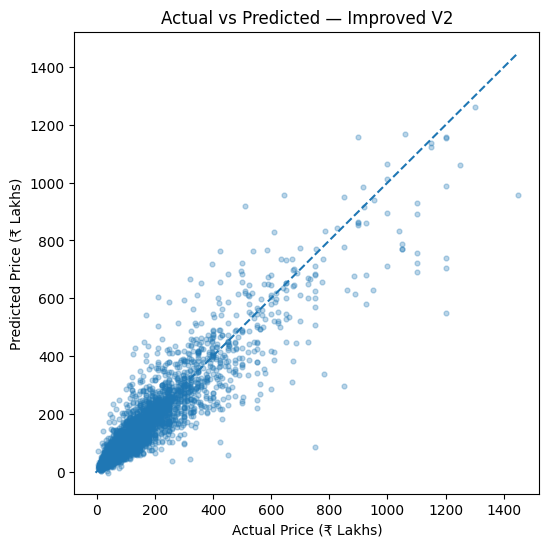

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(y_test/1e5, test_pred/1e5, alpha=.3, s=12)
lo = min((y_test/1e5).min(), (test_pred/1e5).min())
hi = max((y_test/1e5).max(), (test_pred/1e5).max())
plt.plot([lo,hi],[lo,hi],linestyle="--")
plt.xlabel("Actual Price (₹ Lakhs)")
plt.ylabel("Predicted Price (₹ Lakhs)")
plt.title("Actual vs Predicted — Improved V2")
plt.show()

# 13. Model Saving

The entire V2 pipeline is saved with Joblib. This means the Flask app reuses the same feature engineering, rare-category handling and trained model used in this notebook.

In [17]:
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
model_path = MODEL_DIR / "best_house_price_pipeline_v2.joblib"
joblib.dump(final_model, model_path)
print("Saved:", model_path)

Saved: /mnt/data/House_Price_Prediction_System_Improved_V2/models/best_house_price_pipeline_v2.joblib


# 14. Sample Prediction

The prediction form now accepts optional locality and society/project information. These inputs materially improve geographic sensitivity when they match learned patterns; unseen values are safely mapped to an `other` category.

In [18]:
sample_property = pd.DataFrame([{
    "location":"thane",
    "locality_hint":"pokhran road",
    "society":"dosti vihar",
    "property_type":"apartment",
    "bhk":2,
    "area_sqft":1200,
    "current_floor":5,
    "total_floors":14,
    "bathrooms":2,
    "balconies":1,
    "parking":1,
    "transaction":"resale",
    "furnishing":"semi-furnished",
    "facing":"east",
    "ownership":"freehold",
    "overlooking":"garden/park",
}])
loaded = joblib.load(model_path)
print("Sample prediction: ₹{:,.0f}".format(float(loaded.predict(sample_property)[0])))

Sample prediction: ₹12,849,308


# 15. Application / API Development

The project includes a Flask application with:
- `/` — dashboard,
- `/predict` — improved prediction form,
- `/dataset` — EDA and cleaning summary,
- `/model-info` — model comparison,
- `/about` — complete ML lifecycle,
- `/api/predict` — JSON API,
- `/health` — deployment health endpoint.

# 16. Deployment

The repository includes `requirements.txt`, `Procfile`, `render.yaml` and Gunicorn support.

**Render configuration:**
- Build command: `pip install -r requirements.txt`
- Start command: `gunicorn app:app`
- Health check: `/health`

A real public URL requires authorization to the project owner's GitHub/Render account, so the package is deployment-ready without falsely claiming that it is already hosted.

# 17. Limitations and Future Improvements

- The target is a **listing price**, not guaranteed final transaction price.
- Locality is extracted from title text and is imperfect.
- Society is missing for many records.
- Time/market-cycle features are absent.
- 0.99 R² is **not guaranteed** and should not be pursued by using price-derived leakage or duplicate overlap.

Possible future improvements: latitude/longitude, property age, true transaction records, macroeconomic/time features, Optuna tuning, SHAP explanations and prediction intervals.

# 18. Conclusion

Improved V2 demonstrates a stronger but still defensible end-to-end ML workflow. It improves prediction by using locality/project context and LightGBM while preserving train/validation/test separation and excluding circular price-per-square-foot information.

For viva/demo, report the **final test R²**, not the validation score, as the primary generalization result.